# Data-Driven Optimization with Machine Learning Applications
## Assignment 1 
**AIMS Rwanda**

**Student Name:** Joachim SINYABE DANBE  


## Question 1: Singular Value Decomposition (SVD)

### 1a) The Timbuktu Image

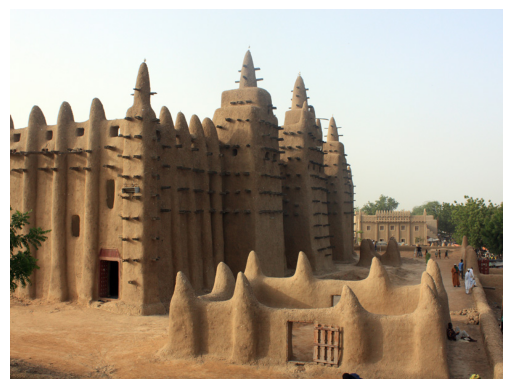

In [15]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

img = Image.open("Timbuktu.png")
plt.imshow(img)
plt.axis("off")
plt.show()


### 1b) The colored image into a gray level image

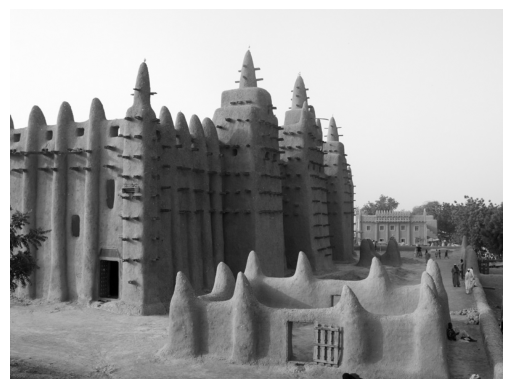

In [18]:
img_gray = img.convert("L")

A = np.array(img_gray, dtype = float)
plt.imshow(img_gray, cmap = "gray")
plt.axis("off")
plt.show()

### 1c) Sparsity Structure

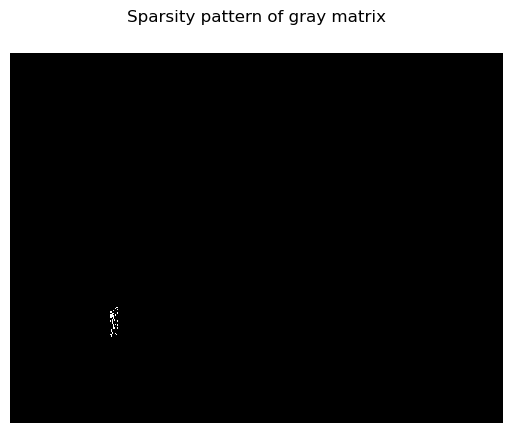

In [19]:
plt.figure()
plt.spy(A)
plt.title("Sparsity pattern of gray matrix")
plt.axis("off")
plt.show()


This sparsity pattern plot reveals the distribution of non-zero elements in the grayscale image matrix. The visualization displays:

Mostly black background: Represents zero or near-zero pixel values (sparse regions)
Small white cluster: Shows the concentration of non-zero values (dense regions with actual image content)

### 1d) SVD of gray‑level image

In [23]:
U,s,Vt = np.linalg.svd(A)
S = np.diag(s)

U.shape, S.shape, Vt.shape

((600, 600), (600, 600), (800, 800))

The SVD decomposition produces three matrices: $U (600×600)$, $Σ (600×600)$, and $V^T (800×800)$. The difference in dimensions reflects that the original grayscale image has 600 rows and 800 columns, with the decomposition capturing all 600 singular values.

### 1e) 30%, 50%, 80% compressions

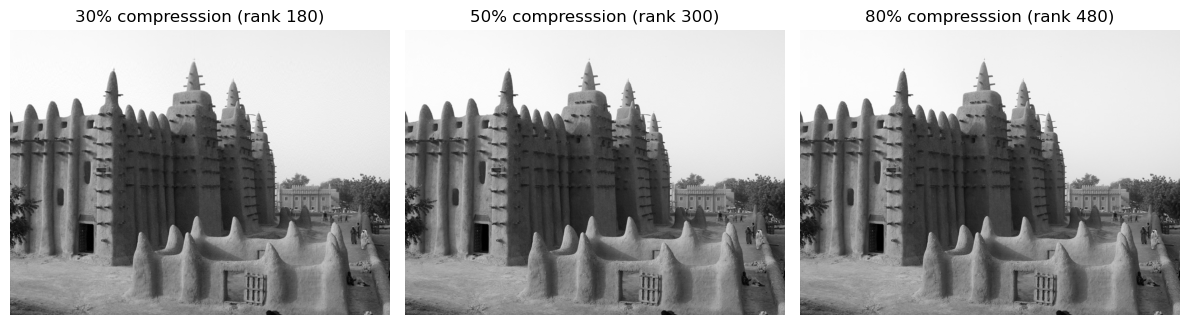

In [24]:
m = len(s)

ranks = {
    "30%" : int(0.30*m),
    "50%" : int(0.50*m),
    "80%" : int(0.80*m)
}

fig, axes = plt.subplots(1,3, figsize = (12,4))

for ax, (label, r) in zip(axes, ranks.items()):
    Ar = U[:,:r]@ np.diag(s[:r])@Vt[:r,:]
    Ar_clipped = np.clip(Ar,0, 255)
    ax.imshow(Ar_clipped, cmap = "gray")
    ax.set_title(f"{label} compresssion (rank {r})")
    ax.axis("off")

plt.tight_layout()
plt.show()



- The visual improvement from 50% to 80% is much smaller than from 30% to 50%, demonstrating that most image information is captured by the first few hundred singular values

- The fact that 50% compression still looks good confirms that the image's "energy" (information) is concentrated in the larger singular values

## Question 5

Given: $f(x) = x_1^2 e^{(1-x_1^2)} - 20.25(x_1 - x_2)^2$

### 5(ii) Using Automatic Differentiation



In [26]:
!pip install autograd

In [1]:
import autograd.numpy as np

from autograd import grad, hessian        


def f(x):
    x1, x2 = x[0], x[1]

    f_x = x1**2 * np.exp(1 - x1**2)-20.25 * (x1 - x2)**2
    return f_x


x_point = np.array([0.0, -1.0])


grad_f = grad(f)
hessian_f = hessian(f)


gradient_at_x = grad_f(x_point)
hessian_at_x = hessian_f(x_point)

print("Results at x = (0, -1) \n")
print(f"Gradient: \n{gradient_at_x}\n")
print(f"Hessian Matrix: \n{hessian_at_x}")


Results at x = (0, -1) 

Gradient: 
[-40.5  40.5]

Hessian Matrix: 
[[-35.06343634  40.5       ]
 [ 40.5        -40.5       ]]


At point x=(0, -1), the gradient is $[-40.5, 40.5]$, indicating the function increases in the positive x₂ direction and decreases in the positive x₁ direction. The Hessian matrix shows the curvature properties, with negative diagonal elements suggesting the function is locally concave in both coordinate directions at this point.

***The results confirm the manual computation***

## Question 6 

$f(x) = (x_1^2 + x_2 - 11)^2 + (x_1 + x_2^2 - 7)^2$ at the point $(1, -1)$ 

### 6a) & 6b) Import Libraries

In [34]:
#!pip install torch jax jaxlib

### 6c) Python Implementation and Comparison

#### Using PyTorch (autograd)

In [33]:
import torch

x = torch.tensor([1.0, -1.0], requires_grad=True)

f_torch = (x[0]**2 + x[1] - 11)**2 + (x[0] + x[1]**2 - 7)**2

f_torch.backward()
grad_pytorch = x.grad

print(f"PyTorch Gradient: {grad_pytorch.numpy()}")


PyTorch Gradient: [-54.  -2.]


PyTorch's automatic differentiation computed the gradient as $[-54, -2]$ at the given point, showing the rate of change of the function in each direction.

#### Using JAX (grad)

In [12]:
import jax
import jax.numpy as jnp


def f_jax(x):
    return (x[0]**2 + x[1] - 11)**2 + (x[0] + x[1]**2 - 7)**2

x_jax = jnp.array([1.0, -1.0])


grad_func = jax.grad(f_jax)
grad_jax_val = grad_func(x_jax)

print(f"JAX Gradient: {grad_jax_val}")


JAX Gradient: [-54.  -2.]


## Question 7

  $f(x) = (x_1^2 + x_2 - 11)^2 + (x_1 + x_2^2 - 7)^2$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


def f(x1, x2):
    return (x1**2 + x2 - 11)**2 + (x1 + x2**2 - 7)**2


x1 = np.linspace(-6, 6, 100)
x2 = np.linspace(-6, 6, 100)
X1, X2 = np.meshgrid(x1, x2)
Z = f(X1, X2)

***7a) 3D surface plot of the function***

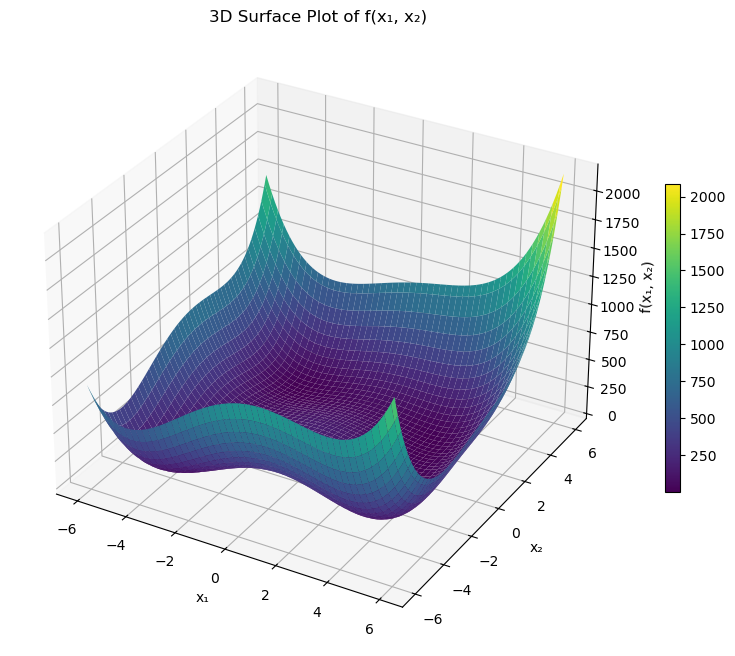

In [2]:
# Figure 1 : 3D surface plot
fig1 = plt.figure(figsize=(10, 8))
ax1 = fig1.add_subplot(111, projection='3d')
surf = ax1.plot_surface(X1, X2, Z, cmap='viridis')
ax1.set_title('3D Surface Plot of f(x₁, x₂)')
ax1.set_xlabel('x₁')
ax1.set_ylabel('x₂')
ax1.set_zlabel('f(x₁, x₂)')
fig1.colorbar(surf, ax=ax1, shrink=0.5)

The surface plot reveals the function has four distinct local minima (valleys), which is a characteristic signature of non-convex functions. A convex function would have only one global minimum

***7b) contour plot of the function***

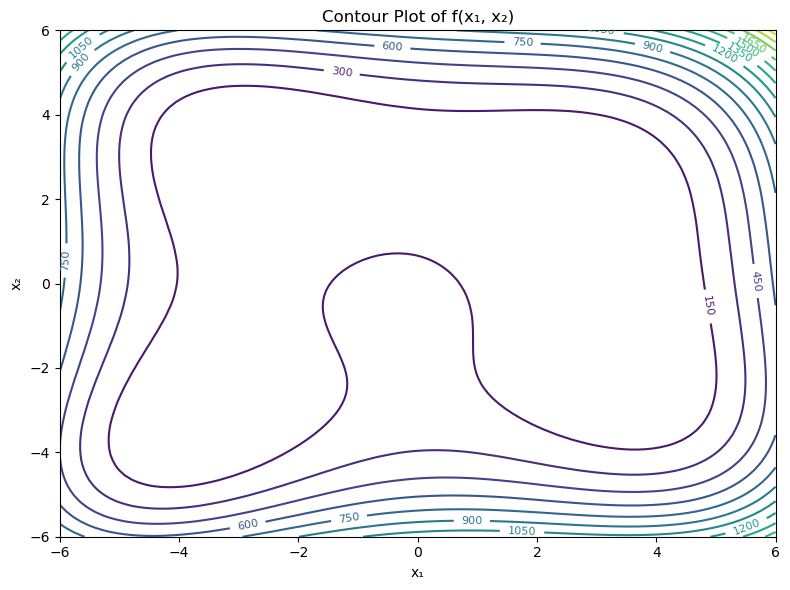

In [3]:
: Contour plot
fig2 = plt.figure(figsize=(8, 6))
ax2 = fig2.add_subplot(111)
contour = ax2.contour(X1, X2, Z, levels=20)
ax2.clabel(contour, inline=True, fontsize=8)
ax2.set_title('Contour Plot of f(x₁, x₂)')
ax2.set_xlabel('x₁')
ax2.set_ylabel('x₂')

plt.tight_layout()
plt.show()